# VACE Pipeline Ver01

このノートブックは `/workspace/scripts/run_vace_id0.sh` の処理を 1 step ずつ追うための説明用 notebook です。

やることは次の 3 つです。

1. bash スクリプトが何をしているかを分解する
2. Python 側でどのように入力動画 1 本を処理するかを確認する
3. 生成済みの出力動画があれば、最後のフレームを画像として表示する

重い VACE 推論は notebook を開いた瞬間には走らせません。必要なら途中のセルから明示的に実行できます。

In [16]:
from pathlib import Path
import csv
import json
import shlex
import subprocess
import zipfile

import pandas as pd
import yaml
from IPython.display import Markdown, display

PROJECT_ROOT = Path('/workspace')
SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'run_vace_id0.sh'
RUN_SH_PATH = PROJECT_ROOT / 'scripts' / 'run.sh'
ENTRY_PY = PROJECT_ROOT / 'src' / 'run_experiment.py'
BASE_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'base.yaml'
OVERRIDE_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'vace_test_only_1_case.yaml'
INPUT_DIR = PROJECT_ROOT / 'data' / 'default' / 'train' / 'videos'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SCRIPT_PATH   =', SCRIPT_PATH)
print('INPUT_DIR     =', INPUT_DIR)

PROJECT_ROOT = /workspace
SCRIPT_PATH   = /workspace/scripts/run_vace_id0.sh
INPUT_DIR     = /workspace/data/default/train/videos


## Step 1. 入口の bash スクリプトをそのまま読む

`run_vace_id0.sh` は薄いラッパーです。主な役割は次の通りです。

- プロジェクトルートへ移動する
- override config を指定する
- `test_instructions.csv` から `video_id=0` の instruction を抜く
- `rows=1` を渡して、数値ソート先頭の `0.mp4` だけ処理する
- 実行本体 `scripts/run.sh -> src/run_experiment.py` を呼ぶ

In [17]:
print(SCRIPT_PATH.read_text())

#!/usr/bin/env bash
set -euo pipefail

PROJECT_ROOT=$(cd "$(dirname "$0")/.." && pwd)
cd "$PROJECT_ROOT"

ENTRY_PY="src/run_experiment.py"
CONFIG_OVERRIDE="configs/vace_test_only_1_case.yaml"
INPUT_DIR="data/default/train/videos"
OUTPUT_ZIP="submission_vace_id0.zip"

# id=0 の instruction を CSV から取得（見つからなければ既定値）
ID0_PROMPT=$(grep '^0,' "$INPUT_DIR/test_instructions.csv" | head -1 | cut -d',' -f2- || true)
PROMPT=${ID0_PROMPT:-"Use instruction set"}

# rows=1 なので数値ソート先頭の 0.mp4 のみ処理
# strict=1 で失敗時は即停止
PYTHON_BIN=/usr/bin/python3 bash scripts/run.sh \
  "$ENTRY_PY" \
  "$CONFIG_OVERRIDE" \
  "$INPUT_DIR" \
  "$PROMPT" \
  "$OUTPUT_ZIP" \
  1 \
  1

echo "[INFO] Done: $OUTPUT_ZIP (saved under logs/<stage>/<exp_id>/)"



## Step 2. bash 変数を Python で再現する

ここでは shell の中で決まる値を、そのまま notebook 上で見える形にします。

In [18]:
ENTRY_PY_REL = 'src/run_experiment.py'
CONFIG_OVERRIDE_REL = 'configs/vace_test_only_1_case.yaml'
INPUT_DIR_REL = 'data/default/train/videos'
OUTPUT_ZIP = 'submission_vace_id0.zip'

instructions_df = pd.read_csv(INPUT_DIR / 'test_instructions.csv')
id0_row = instructions_df.loc[instructions_df['video_id'] == 0].iloc[0]
ID0_PROMPT = id0_row['instruction']
PROMPT = ID0_PROMPT if isinstance(ID0_PROMPT, str) and ID0_PROMPT else 'Use instruction set'

resolved = {
    'ENTRY_PY': ENTRY_PY_REL,
    'CONFIG_OVERRIDE': CONFIG_OVERRIDE_REL,
    'INPUT_DIR': INPUT_DIR_REL,
    'OUTPUT_ZIP': OUTPUT_ZIP,
    'ID0_PROMPT': ID0_PROMPT,
    'PROMPT': PROMPT,
    'ROWS': 1,
    'STRICT': 1,
}

# 表示が切れないように設定する
pd.set_option('display.max_colwidth', None)

display(pd.DataFrame([resolved]).T.rename(columns={0: 'value'}))

,value
ENTRY_PY,src/run_experiment.py
CONFIG_OVERRIDE,configs/vace_test_only_1_case.yaml
INPUT_DIR,data/default/train/videos
OUTPUT_ZIP,submission_vace_id0.zip
ID0_PROMPT,Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.
PROMPT,Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.
ROWS,1
STRICT,1


## Step 3. 実際に shell から何が呼ばれるかを確認する

`scripts/run.sh` はさらに薄く、最終的には Python エントリポイントに引数をそのまま渡します。

In [19]:
print(RUN_SH_PATH.read_text())

#!/usr/bin/env bash
set -e
PROJECT_ROOT=$(cd "$(dirname "$0")/.." && pwd)
cd "$PROJECT_ROOT"

ENTRY_PY=${1:-src/run_experiment.py}
CONFIG_PATH=${2:-configs/base.yaml}
shift $(( $# >= 2 ? 2 : $# ))

exec ${PYTHON_BIN:-/usr/bin/python3} "$ENTRY_PY" "$CONFIG_PATH" "$@"


In [20]:
shell_command = [
    'PYTHON_BIN=/usr/bin/python3',
    'bash', 'scripts/run.sh',
    ENTRY_PY_REL,
    CONFIG_OVERRIDE_REL,
    INPUT_DIR_REL,
    PROMPT,
    OUTPUT_ZIP,
    '1',
    '1',
]

print(' '.join(shlex.quote(x) for x in shell_command))

PYTHON_BIN=/usr/bin/python3 bash scripts/run.sh src/run_experiment.py configs/vace_test_only_1_case.yaml data/default/train/videos 'Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.' submission_vace_id0.zip 1 1


## Step 4. Python 側の引数と設定ファイルを確認する

`src/run_experiment.py` は以下を担当します。

- base config と override config のマージ
- 実験ディレクトリ `logs/<stage>/<exp_id>/` の作成
- directory 入力なら `VideoProcessor.process_directory(...)` を呼ぶ
- `result.json` と `exp_summary.csv` を保存する

In [21]:
base_config = yaml.safe_load(BASE_CONFIG_PATH.read_text())
override_config = yaml.safe_load(OVERRIDE_CONFIG_PATH.read_text())

def deep_merge_dict(base, override):
    merged = dict(base)
    for key, value in override.items():
        if key in merged and isinstance(merged[key], dict) and isinstance(value, dict):
            merged[key] = deep_merge_dict(merged[key], value)
        else:
            merged[key] = value
    return merged

merged_config = deep_merge_dict(base_config, override_config)
display(Markdown('### base.yaml'))
display(base_config)
display(Markdown('### vace_test_only_1_case.yaml'))
display(override_config)
display(Markdown('### merged config'))
display(merged_config)

### base.yaml

{'output': {'base_dir': './logs',
  'exp_name': 'baseline_vace',
  'exp_content': 'frame一致を重視したVACE baseline検証'},
 'preprocess': {'long_side': 512},
 'model': {'vace_repo': './third_party/VACE',
  'model_path': './third_party/VACE/models/VACE-Wan2.1-1.3B-Preview',
  'entry_script': 'inference.py',
  'identity_fallback': True},
 'inference': {'seed': 42, 'steps': 25},
 'runtime': {'device': 'cuda'},
 'evaluation': {'enable': True}}

### vace_test_only_1_case.yaml

{'output': {'exp_name': 'vace_test_only_1_case',
  'exp_content': '1個の.mp4だけ VACEで処理をして、instruction通りの変化担っているか？ コンペ出力になっているか？ を確認する'}}

### merged config

{'output': {'base_dir': './logs',
  'exp_name': 'vace_test_only_1_case',
  'exp_content': '1個の.mp4だけ VACEで処理をして、instruction通りの変化担っているか？ コンペ出力になっているか？ を確認する'},
 'preprocess': {'long_side': 512},
 'model': {'vace_repo': './third_party/VACE',
  'model_path': './third_party/VACE/models/VACE-Wan2.1-1.3B-Preview',
  'entry_script': 'inference.py',
  'identity_fallback': True},
 'inference': {'seed': 42, 'steps': 25},
 'runtime': {'device': 'cuda'},
 'evaluation': {'enable': True}}

## Step 5. 入力ディレクトリの中身を見る

`VideoProcessor.process_directory(...)` はまず `*.mp4` を数値優先でソートします。なので `rows=1` のとき最初に選ばれるのは `0.mp4` です。

合わせて `metadata.csv` と `test_instructions.csv` を読み、フレーム数と instruction を決めます。

In [22]:
video_files = sorted(
    [p for p in INPUT_DIR.glob('*.mp4') if p.is_file()],
    key=lambda p: ((0, int(p.stem)) if p.stem.isdigit() else (1, p.stem)),
)

metadata_df = pd.read_csv(INPUT_DIR / 'metadata.csv')
instructions_df = pd.read_csv(INPUT_DIR / 'test_instructions.csv')

selected_video = video_files[0]
selected_row = metadata_df.loc[metadata_df['video_path'] == str(selected_video.resolve())].iloc[0]

summary_df = pd.DataFrame([
    {
        'selected_video': str(selected_video),
        'frame_count': int(selected_row['frame']),
        'fps': float(selected_row['fps']),
        'width': int(selected_row['width']),
        'height': int(selected_row['height']),
        'instruction': PROMPT,
    }
])

display(summary_df)
display(instructions_df.head())

,selected_video,frame_count,fps,width,height,instruction
0,/workspace/data/default/train/videos/0.mp4,125,25.0,1920,1080,Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.


,video_id,instruction
0,0,Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.
1,1,Shift the entire color palette to warm golden tones with enhanced saturation.
2,2,Increase the count of objects in the scene by adding three more similar items to the foreground.
3,3,Add heavy fog and mist to create an atmospheric environmental effect.
4,4,Insert a large glowing orb floating in the center of the scene.


## Step 6. `VideoProcessor` が最終的に何をやるかを手で展開する

1 件だけ処理する場合の重要な中間生成物は次の通りです。

- `logs/train/<exp_id>/instruction.txt`
- `logs/train/<exp_id>/instruction_manifest.csv`
- `logs/train/<exp_id>/tmp/model_out_0000.mp4`
- `logs/train/<exp_id>/videos/0.mp4`
- `logs/train/<exp_id>/submission_vace_id0.zip`
- `logs/train/<exp_id>/result.json`

In [23]:
stage = 'train'
exp_name = merged_config['output']['exp_name']
display({'stage': stage, 'exp_name': exp_name})

existing_exp_dirs = sorted(
    (PROJECT_ROOT / 'logs' / stage).glob(f'{exp_name}_*')
)
pd.DataFrame({'existing_exp_dir': [str(p) for p in existing_exp_dirs]})

{'stage': 'train', 'exp_name': 'vace_test_only_1_case'}

,existing_exp_dir
0,/workspace/logs/train/vace_test_only_1_case_20260322_083814
1,/workspace/logs/train/vace_test_only_1_case_20260322_083832
2,/workspace/logs/train/vace_test_only_1_case_20260322_085052


## Step 7. VACE 実行コマンドを組み立てる

`VaceExecutor.execute(...)` は内部で `third_party/VACE/vace/vace_wan_inference.py` を subprocess 実行します。

ここでは、`0.mp4` に対して実際にどんなコマンドが作られるかを可視化します。

In [24]:
vace_repo = (PROJECT_ROOT / merged_config['model']['vace_repo']).resolve()
vace_ckpt_dir = (PROJECT_ROOT / merged_config['model']['model_path']).resolve()
vace_script = (vace_repo / 'vace' / 'vace_wan_inference.py').resolve()

latest_exp_dir = existing_exp_dirs[-1] if existing_exp_dirs else None
if latest_exp_dir is None:
    latest_exp_dir = PROJECT_ROOT / 'logs' / stage / f'{exp_name}_EXAMPLE'

tmp_dir = latest_exp_dir / 'tmp'
row_save_dir = tmp_dir / 'vace_run_0000'
row_out = tmp_dir / 'model_out_0000.mp4'
frame_num = int(selected_row['frame'])

vace_cmd = [
    '/usr/bin/python3',
    str(vace_script),
    '--ckpt_dir', str(vace_ckpt_dir),
    '--src_video', str(selected_video.resolve()),
    '--prompt', PROMPT,
    '--base_seed', str(merged_config['inference']['seed']),
    '--sample_steps', str(merged_config['inference']['steps']),
    '--frame_num', str(frame_num),
    '--save_dir', str(row_save_dir.resolve()),
    '--save_file', str(row_out.resolve()),
]

print(' '.join(shlex.quote(x) for x in vace_cmd))
print('\ncheckpoint exists =', vace_ckpt_dir.exists())
print('vace script exists =', vace_script.exists())

/usr/bin/python3 /workspace/third_party/VACE/vace/vace_wan_inference.py --ckpt_dir /workspace/third_party/VACE/models/VACE-Wan2.1-1.3B-Preview --src_video /workspace/data/default/train/videos/0.mp4 --prompt 'Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.' --base_seed 42 --sample_steps 25 --frame_num 125 --save_dir /workspace/logs/train/vace_test_only_1_case_20260322_085052/tmp/vace_run_0000 --save_file /workspace/logs/train/vace_test_only_1_case_20260322_085052/tmp/model_out_0000.mp4

checkpoint exists = True
vace script exists = True


## Step 8. 必要なら notebook から実行する

次のセルはコメントアウトされた状態で置いてあります。重い処理なので、必要なときだけコメントを外して実行してください。

実行に成功すると、`logs/train/<exp_id>/videos/0.mp4` と `submission_vace_id0.zip` が作られます。

In [25]:
# cmd = [
#     'bash',
#     str(SCRIPT_PATH),
# ]
# completed = subprocess.run(
#     cmd,
#     cwd=str(PROJECT_ROOT),
#     stdout=subprocess.PIPE,
#     stderr=subprocess.PIPE,
#     text=True,
# )
# print('returncode =', completed.returncode)
# print('\n[stdout]\n', completed.stdout)
# print('\n[stderr]\n', completed.stderr)

## Step 9. 既存の実行結果を探す

この環境にはすでに `submission_vace_id0.zip` を作成済みの実行結果が存在するので、それを使って downstream の確認を行います。

In [26]:
result_json_candidates = sorted((PROJECT_ROOT / 'logs' / 'train').glob(f'{exp_name}_*/result.json'))
result_records = []
for path in result_json_candidates:
    payload = json.loads(path.read_text())
    payload['result_json'] = str(path)
    result_records.append(payload)

results_df = pd.DataFrame(result_records)
display(results_df)

ok_rows = results_df.loc[results_df['status'] == 'ok'] if not results_df.empty else pd.DataFrame()
latest_ok = ok_rows.iloc[-1].to_dict() if not ok_rows.empty else None
latest_ok

,status,output_path,videos_dir,manifest_path,experiment_dir,success_count,failed_count,result_json
0,ok,data/work/submission_vace_id0.zip,data/work/submission_vace_id0,data/work/submission_vace_id0/instruction_manifest.csv,logs/train/vace_test_only_1_case_20260322_083832,1,0,/workspace/logs/train/vace_test_only_1_case_20260322_083832/result.json
1,ok,logs/train/vace_test_only_1_case_20260322_085052/submission_vace_id0.zip,logs/train/vace_test_only_1_case_20260322_085052/videos,logs/train/vace_test_only_1_case_20260322_085052/instruction_manifest.csv,logs/train/vace_test_only_1_case_20260322_085052,1,0,/workspace/logs/train/vace_test_only_1_case_20260322_085052/result.json


{'status': 'ok',
 'output_path': 'logs/train/vace_test_only_1_case_20260322_085052/submission_vace_id0.zip',
 'videos_dir': 'logs/train/vace_test_only_1_case_20260322_085052/videos',
 'manifest_path': 'logs/train/vace_test_only_1_case_20260322_085052/instruction_manifest.csv',
 'experiment_dir': 'logs/train/vace_test_only_1_case_20260322_085052',
 'success_count': 1,
 'failed_count': 0,
 'result_json': '/workspace/logs/train/vace_test_only_1_case_20260322_085052/result.json'}

## Step 10. zip と manifest の中身を確認する

ここで提出物として何が保存されたかを確認します。`0.mp4` だけが zip に入っていれば、`rows=1` の期待どおりです。

In [27]:
if latest_ok is None:
    raise RuntimeError('成功済みの result.json が見つかりません。Step 8 の実行セルを使って先に生成してください。')

experiment_dir = PROJECT_ROOT / latest_ok['experiment_dir']
zip_path = PROJECT_ROOT / latest_ok['output_path']
manifest_path = PROJECT_ROOT / latest_ok['manifest_path']
videos_dir = PROJECT_ROOT / latest_ok['videos_dir']

print('experiment_dir =', experiment_dir)
print('zip_path       =', zip_path)
print('manifest_path  =', manifest_path)
print('videos_dir     =', videos_dir)

manifest_df = pd.read_csv(manifest_path)
display(manifest_df)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zip_members = zf.namelist()

print('zip members =', zip_members)

experiment_dir = /workspace/logs/train/vace_test_only_1_case_20260322_085052
zip_path       = /workspace/logs/train/vace_test_only_1_case_20260322_085052/submission_vace_id0.zip
manifest_path  = /workspace/logs/train/vace_test_only_1_case_20260322_085052/instruction_manifest.csv
videos_dir     = /workspace/logs/train/vace_test_only_1_case_20260322_085052/videos


,row_index,row_id,instruction,input_frame_count,mode,status
0,0,0,Change the background to a vibrant sunset cityscape while keeping the main subject unchanged.,125,model_direct_vace,ok


zip members = ['0.mp4']


## Step 11. 出力動画の最後のフレームを画像として表示する

最後に、生成された `videos/0.mp4` の最終フレームを読み出して表示します。これで notebook の中で「最後の画像まで確認する」という目的を満たします。

decoded frame_count = 81
output_video = /workspace/logs/train/vace_test_only_1_case_20260322_085052/videos/0.mp4


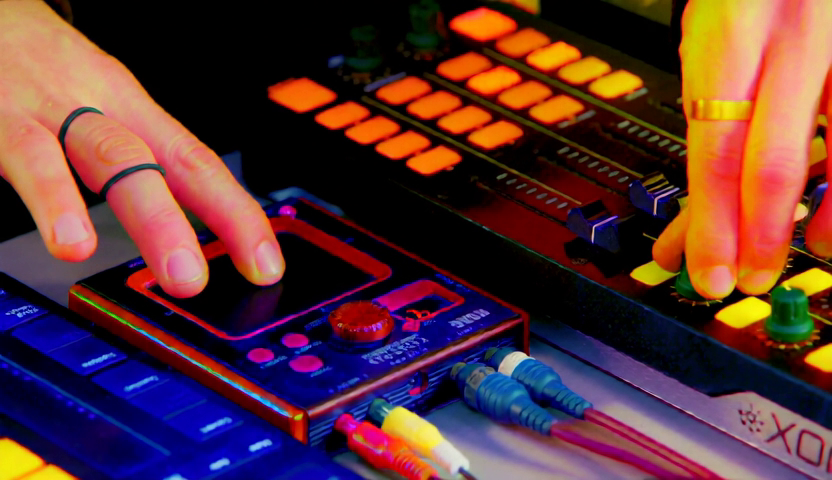

In [28]:
from PIL import Image

try:
    import imageio.v3 as iio
except Exception:
    import imageio as iio

output_video = videos_dir / '0.mp4'
if not output_video.exists():
    raise FileNotFoundError(f'出力動画が見つかりません: {output_video}')

frames = iio.imiter(output_video)
last_frame = None
frame_count = 0
for frame in frames:
    last_frame = frame
    frame_count += 1

print('decoded frame_count =', frame_count)
print('output_video =', output_video)
Image.fromarray(last_frame)

## まとめ

`run_vace_id0.sh` は「id=0 の instruction を選び、`0.mp4` だけを VACE に通して、`logs/train/<exp_id>/` 配下に結果をまとめる」スクリプトです。

特に追うべきファイルは次の 4 つです。

- `scripts/run_vace_id0.sh`: 入口
- `scripts/run.sh`: Python エントリポイント呼び出し
- `src/run_experiment.py`: 実験ディレクトリ管理と分岐
- `src/pipeline/video_processor.py`: 入力動画 1 本の処理本体

最終的な成果物は `videos/0.mp4` と `submission_vace_id0.zip` です。